## Comprehensive Exploratory Data Analysis (EDA)

### By:
Data Science Team

### Date:
2026-02-23

### Description:

This notebook performs a complete Exploratory Data Analysis on the cleaned churn dataset including:
- **Univariable Analysis**: Distribution analysis of individual features
- **Bivariable Analysis**: Relationship analysis between pairs of variables
- **Multivariable Analysis**: Complex relationships and dimensionality reduction (PCA)
- **Feature Importance**: Ranking of features based on their relationship with the target variable

## 📚 Import  libraries

In [22]:
# base libraries for data science
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# Constants for analysis
CORRELATION_THRESHOLD = 0.5
MIN_NUMERICAL_COLS = 2
P_VALUE_SIGNIFICANCE_001 = 0.001
P_VALUE_SIGNIFICANCE_01 = 0.01
P_VALUE_SIGNIFICANCE_05 = 0.05

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
sns.set_palette("husl")

# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

# print library version for reproducibility
print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.12 (main, Feb 12 2026, 00:42:14) [Clang 21.1.4 ]
Pandas version:  2.3.3


## 💾 Load data

In [23]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

# Load the parquet file
df = pd.read_parquet(DATA_DIR / "02_intermediate/churn_cleaned.parquet", engine="pyarrow")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (14214, 18)

First few rows:
   SeniorCitizen Partner Dependents  tenure     MultipleLines InternetService  \
0           0.00     Yes         No    1.00  No phone service             DSL   
1           0.00      No         No   34.00                No             DSL   
2           0.00      No         No    2.00                No             DSL   
3           0.00      No         No   45.00  No phone service             DSL   
4           0.00      No         No    2.00                No     Fiber optic   

  OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV  \
0             No          Yes               No          No          No   
1            Yes           No              Yes          No          No   
2            Yes          Yes               No          No          No   
3            Yes           No              Yes         Yes          No   
4             No           No               No          No          No   

  StreamingMovies       

## 🔍 Exploratory Data Analysis

### 1️⃣ Univariable Analysis
Analysis of individual variables: distributions, outliers, and summary statistics

In [24]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("=" * 80)
print("NUMERICAL COLUMNS ANALYSIS")
print("=" * 80)
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Count: {df[col].count()}")
    print(f"  Mean: {df[col].mean():.4f}")
    print(f"  Median: {df[col].median():.4f}")
    print(f"  Std Dev: {df[col].std():.4f}")
    print(f"  Min: {df[col].min():.4f}")
    print(f"  Max: {df[col].max():.4f}")
    print(f"  Skewness: {stats.skew(df[col].dropna()):.4f}")
    print(f"  Kurtosis: {stats.kurtosis(df[col].dropna()):.4f}")

print("\n" + "=" * 80)
print("CATEGORICAL COLUMNS ANALYSIS")
print("=" * 80)
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Missing values: {df[col].isna().sum()}")

NUMERICAL COLUMNS ANALYSIS

SeniorCitizen:
  Count: 14154
  Mean: 0.1621
  Median: 0.0000
  Std Dev: 0.3685
  Min: 0.0000
  Max: 1.0000
  Skewness: 1.8340


  Kurtosis: 1.3634

tenure:
  Count: 14114
  Mean: 32.3628
  Median: 29.0000
  Std Dev: 24.5688
  Min: 0.0000
  Max: 72.0000
  Skewness: 0.2391
  Kurtosis: -1.3888

MonthlyCharges:
  Count: 14101
  Mean: 372028768.0000
  Median: 70.3500
  Std Dev: 44155453440.0000
  Min: 18.2500
  Max: 5243355004928.0000
  Skewness: 118.7350
  Kurtosis: nan

TotalCharges:
  Count: 14121
  Mean: 384726884.8639
  Median: 1398.2500
  Std Dev: 45809093835.1680
  Min: -9876543456.0000
  Max: 5443567897654.0000
  Skewness: 118.8186
  Kurtosis: 14115.9062

CATEGORICAL COLUMNS ANALYSIS

Partner:
Partner
No     7316
Yes    6837
Name: count, dtype: int64
  Unique values: 2
  Missing values: 61

Dependents:
Dependents
No     9899
Yes    4225
Name: count, dtype: int64
  Unique values: 2
  Missing values: 90

MultipleLines:
MultipleLines
No                  6784
Yes                 5940
No phone service    1352
1244132                1
Name: count, dtype: int64
  Unique values: 4
  Missing values: 137

InternetServ

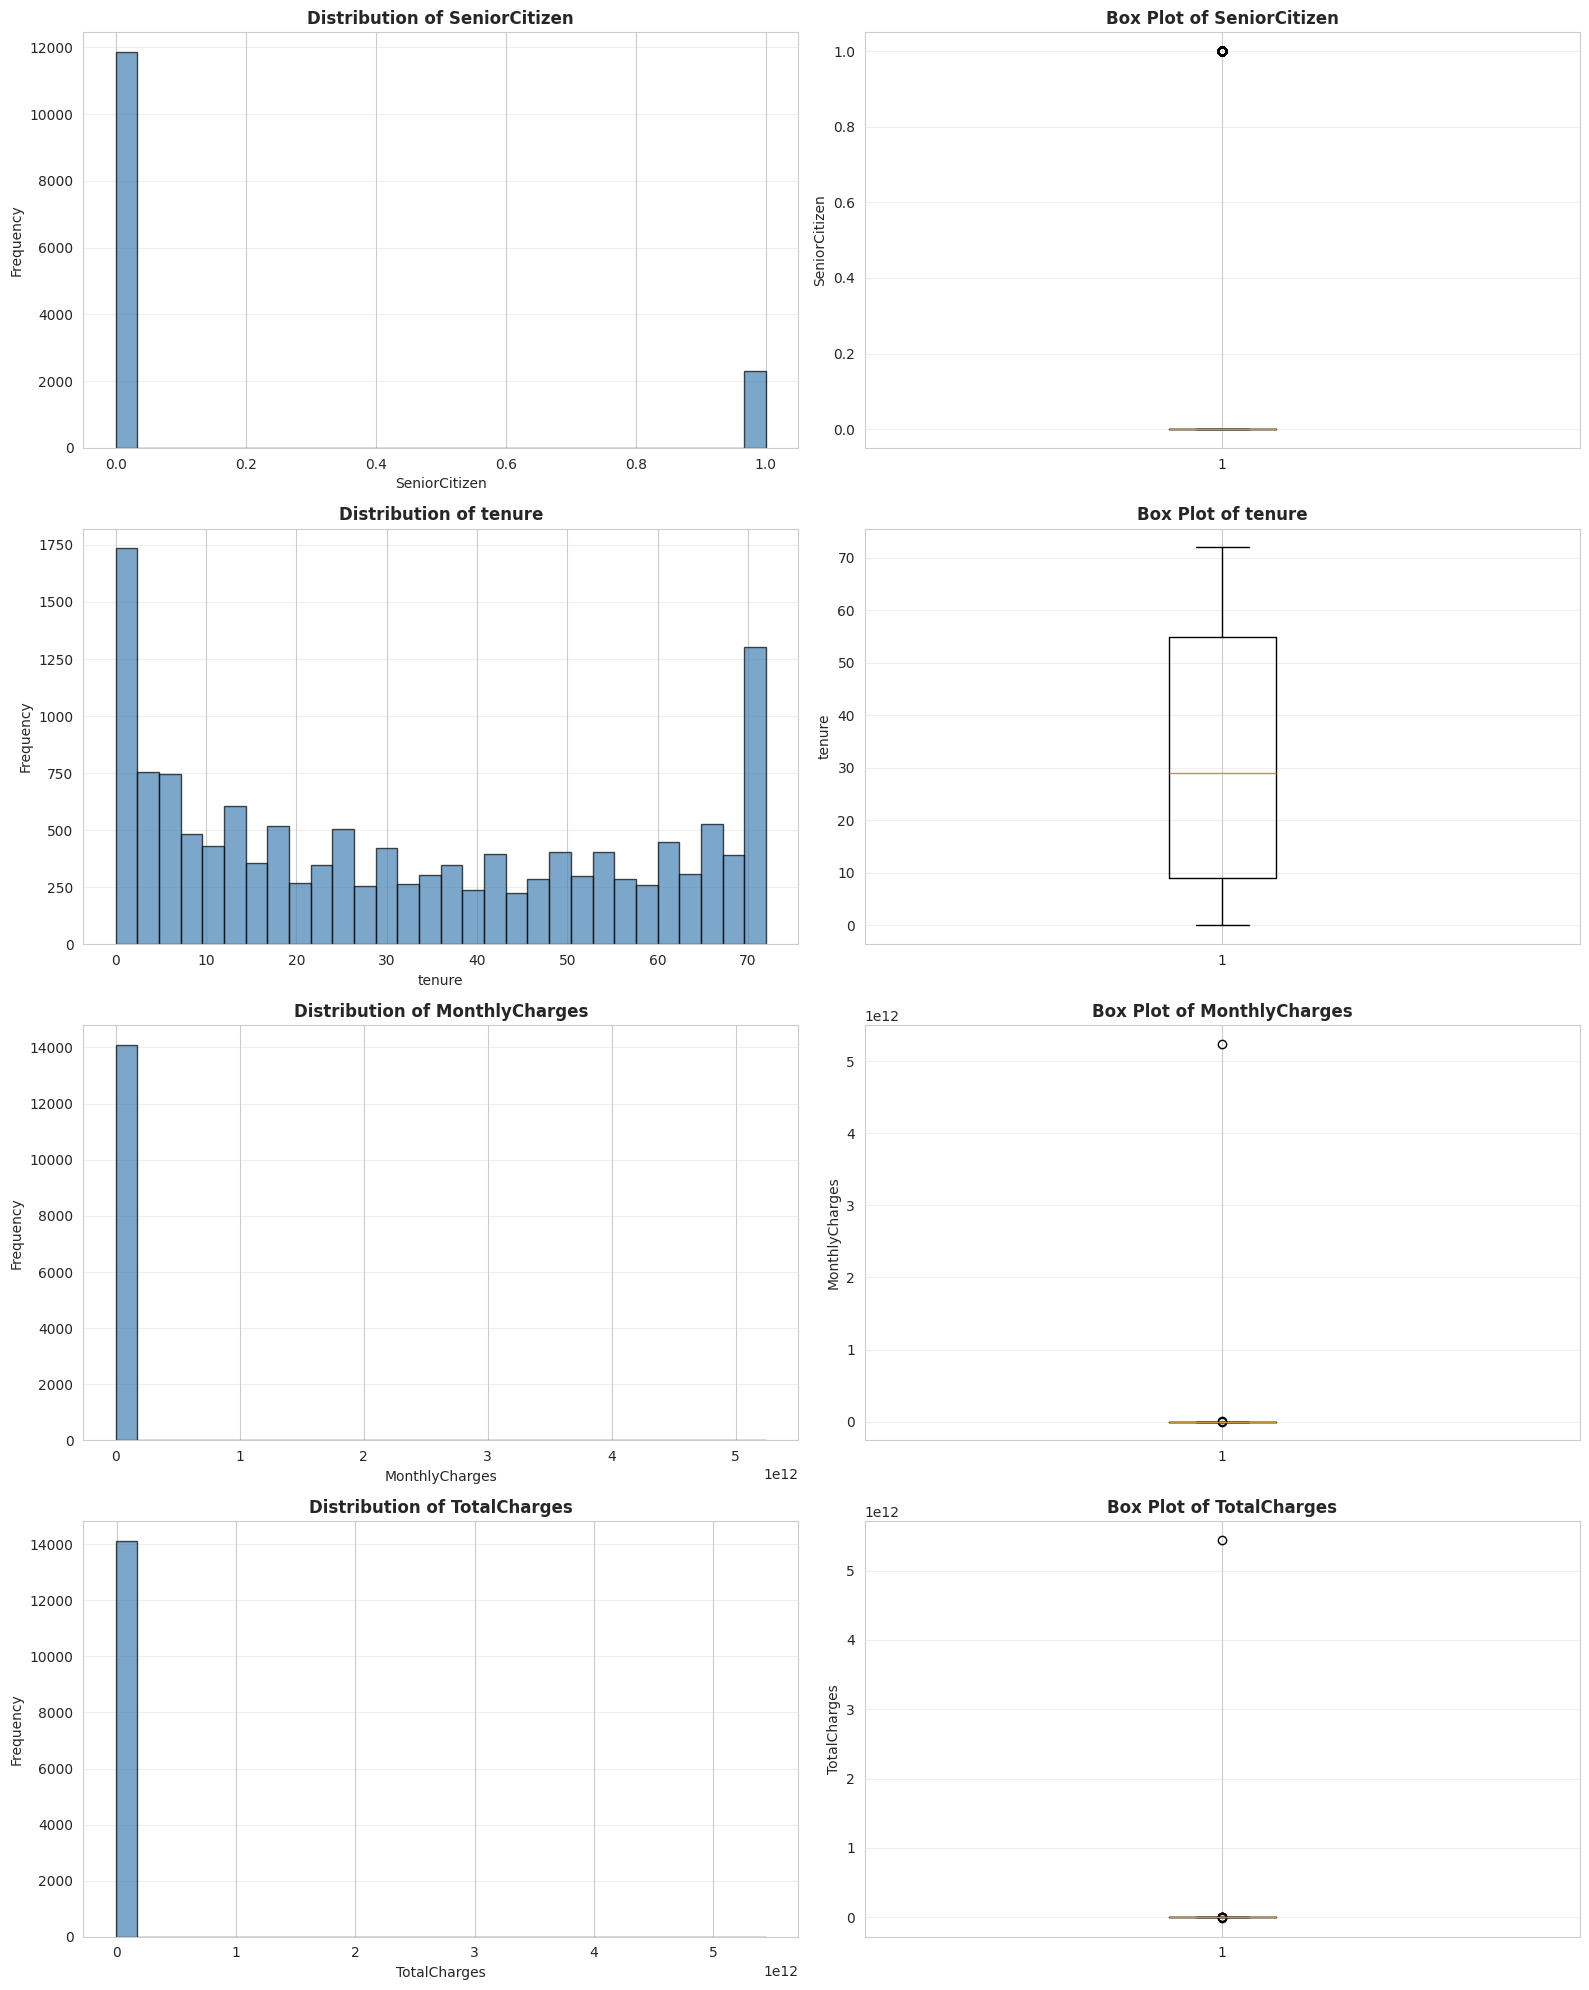

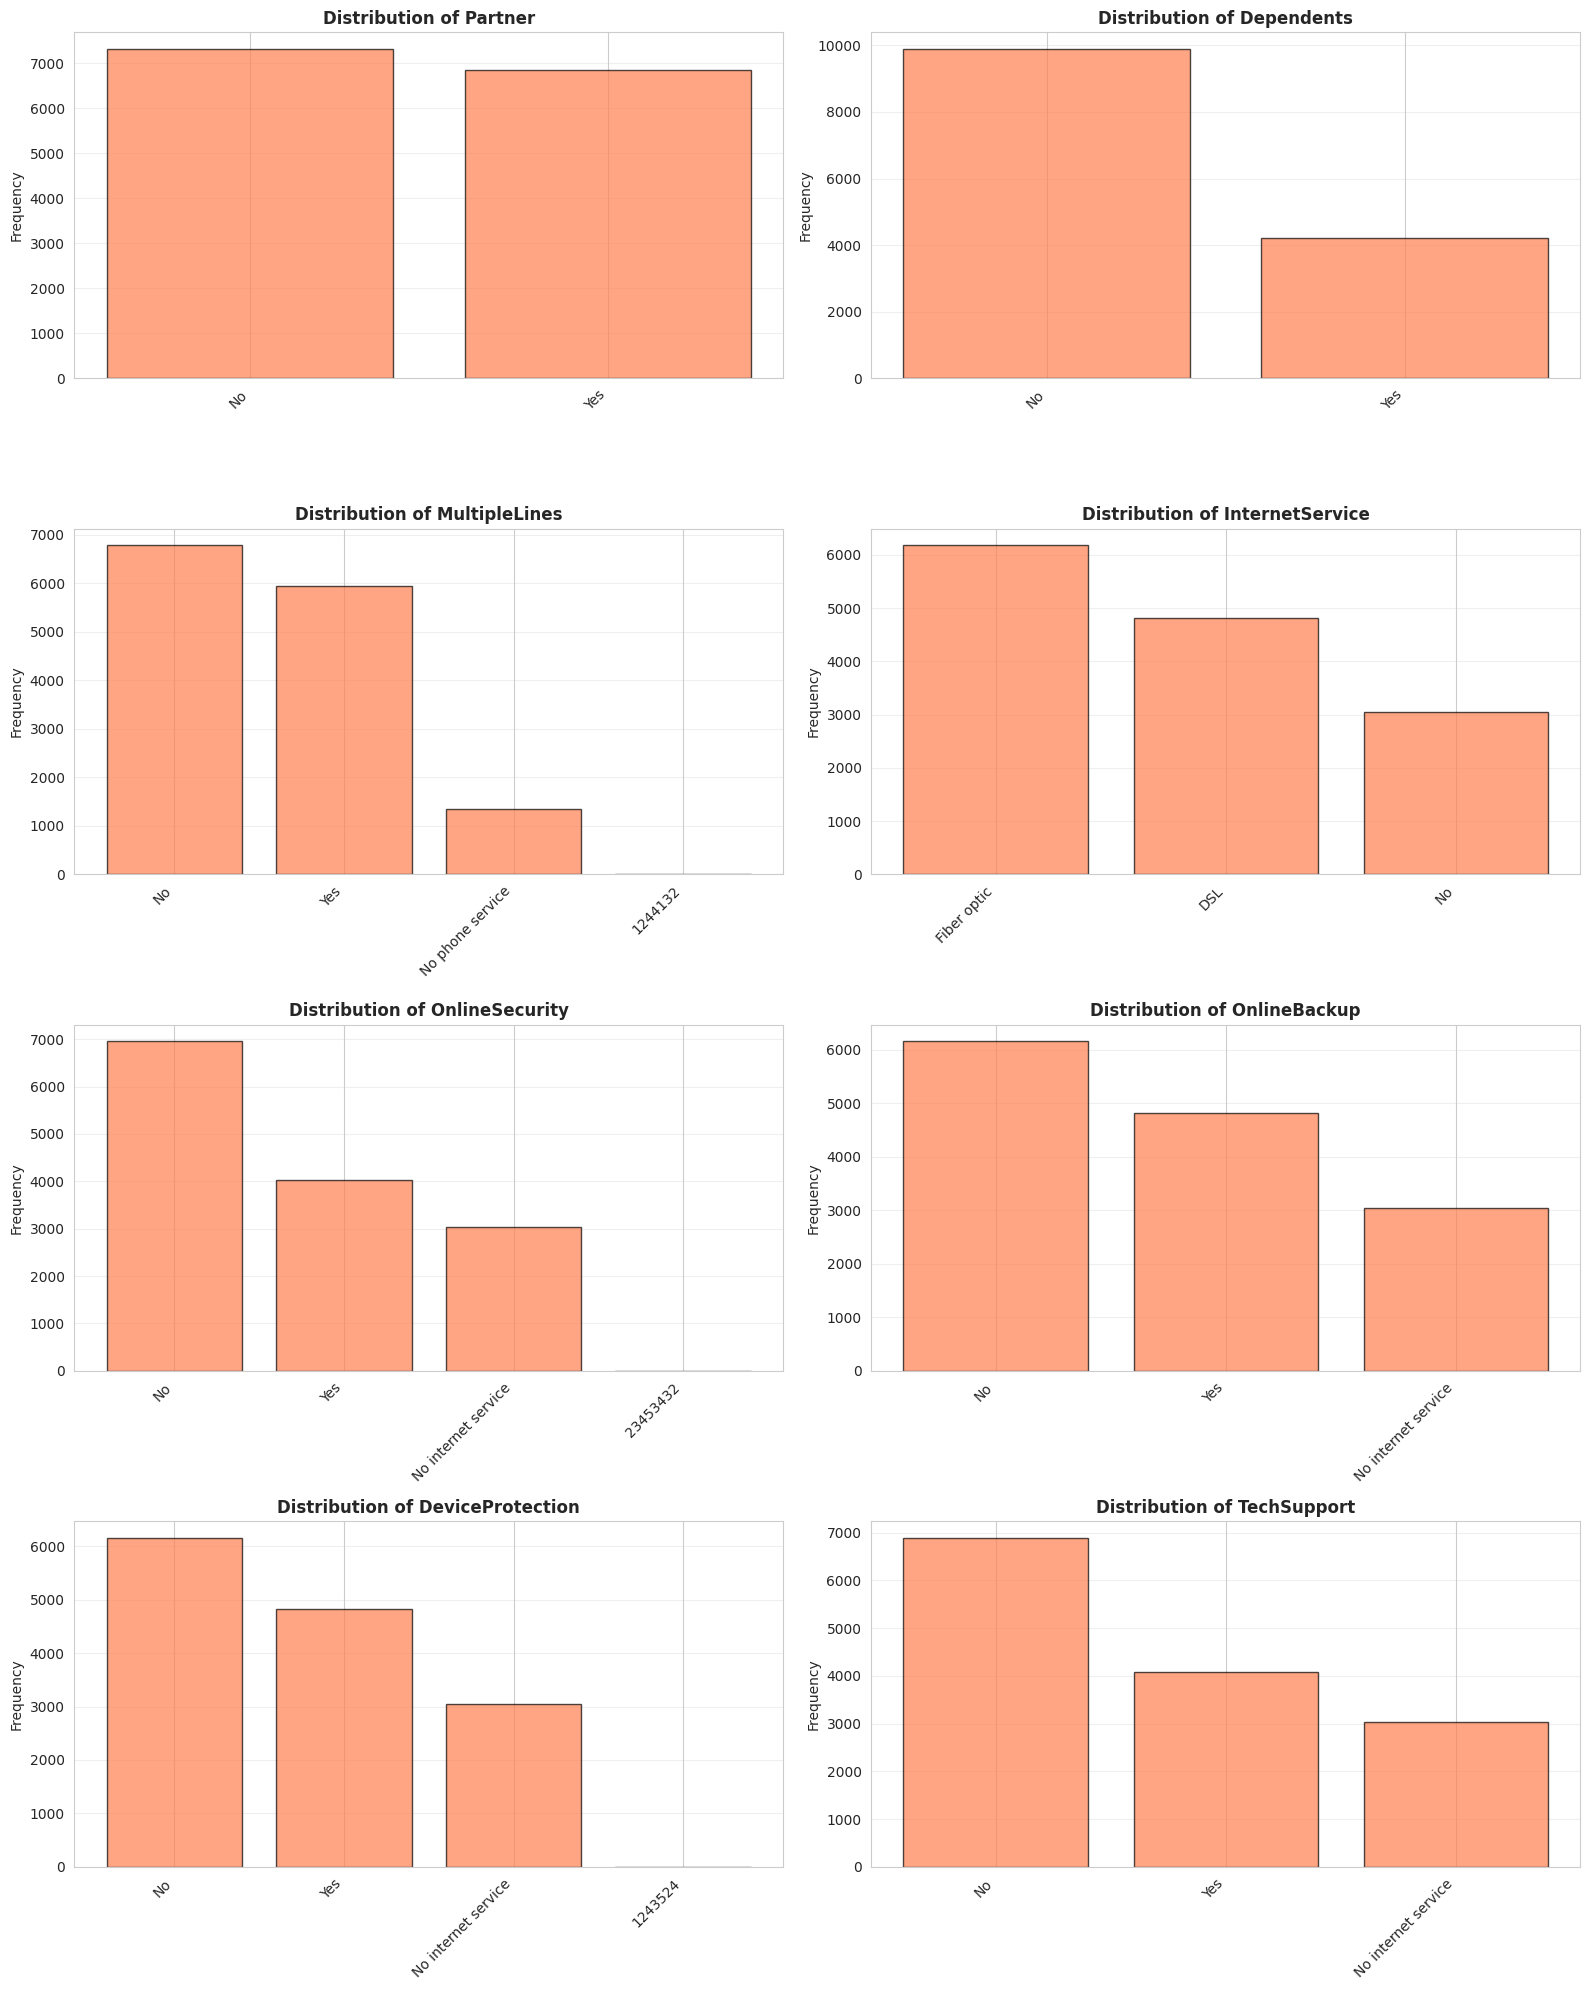


✓ Plotted top 4 numerical features and 8 categorical features
  (Skipped 6 categorical features for performance)


In [25]:
# Visualizations for Numerical Variables - Histograms and Box Plots (Top 5 features)
num_cols_to_plot = numerical_cols[: min(5, len(numerical_cols))]
fig, axes = plt.subplots(len(num_cols_to_plot), 2, figsize=(16, 5 * len(num_cols_to_plot)))
if len(num_cols_to_plot) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(num_cols_to_plot):
    # Histogram
    axes[idx, 0].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    axes[idx, 0].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel("Frequency")
    axes[idx, 0].grid(axis="y", alpha=0.3)

    # Box Plot
    axes[idx, 1].boxplot(df[col].dropna(), vert=True)
    axes[idx, 1].set_title(f"Box Plot of {col}", fontsize=12, fontweight="bold")
    axes[idx, 1].set_ylabel(col)
    axes[idx, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizations for Categorical Variables (Top 8 features)
cat_cols_to_plot = categorical_cols[: min(8, len(categorical_cols))]
fig, axes = plt.subplots(
    (len(cat_cols_to_plot) + 1) // 2, 2, figsize=(16, 5 * ((len(cat_cols_to_plot) + 1) // 2))
)
axes = axes.flatten()

for idx, col in enumerate(cat_cols_to_plot):
    value_counts = df[col].value_counts()
    axes[idx].bar(
        range(len(value_counts)), value_counts.values, color="coral", edgecolor="black", alpha=0.7
    )
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha="right")
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(axis="y", alpha=0.3)

# Hide unused subplots
for idx in range(len(cat_cols_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(
    f"\n✓ Plotted top {len(num_cols_to_plot)} numerical features and {len(cat_cols_to_plot)} categorical features"
)
if len(numerical_cols) > len(num_cols_to_plot):
    print(
        f"  (Skipped {len(numerical_cols) - len(num_cols_to_plot)} numerical features for performance)"
    )
if len(categorical_cols) > len(cat_cols_to_plot):
    print(
        f"  (Skipped {len(categorical_cols) - len(cat_cols_to_plot)} categorical features for performance)"
    )

### 2️⃣ Bivariable Analysis
Analysis of relationships between pairs of variables

In [26]:
# Correlation Matrix for Numerical Variables
if len(numerical_cols) > 1:
    print("=" * 80)
    print("CORRELATION ANALYSIS - NUMERICAL VARIABLES")
    print("=" * 80)
    correlation_matrix = df[numerical_cols].corr()
    print(correlation_matrix)
    print(f"\nHighly correlated pairs (|corr| > {CORRELATION_THRESHOLD}):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > CORRELATION_THRESHOLD:
                print(
                    f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.4f}"
                )

CORRELATION ANALYSIS - NUMERICAL VARIABLES
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02           -0.00          0.02
tenure                   0.02    1.00            0.00         -0.01
MonthlyCharges          -0.00    0.00            1.00         -0.00
TotalCharges             0.02   -0.01           -0.00          1.00

Highly correlated pairs (|corr| > 0.5):


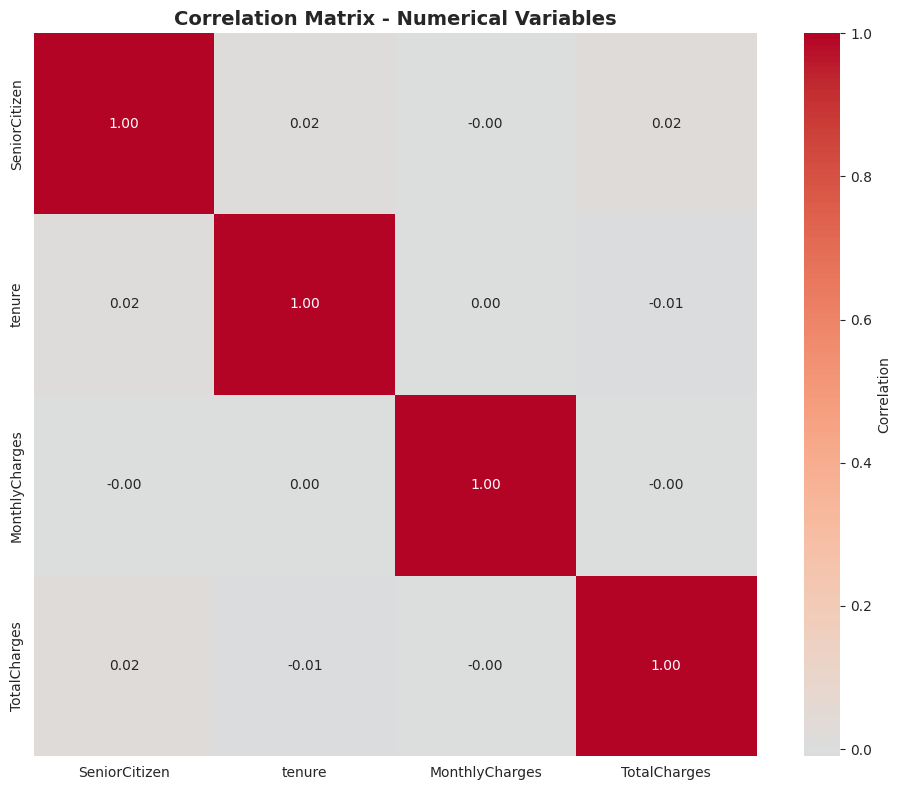

In [27]:
# Visualize Correlation Matrix
if len(numerical_cols) > 1:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        ax=ax,
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title("Correlation Matrix - Numerical Variables", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Scatter plots for highly correlated pairs
    correlated_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > CORRELATION_THRESHOLD:
                correlated_pairs.append(
                    (correlation_matrix.columns[i], correlation_matrix.columns[j], corr_value)
                )

    if correlated_pairs:
        fig, axes = plt.subplots(
            (len(correlated_pairs) + 1) // 2,
            2,
            figsize=(14, 5 * ((len(correlated_pairs) + 1) // 2)),
        )
        axes = axes.flatten()

        for idx, (col1, col2, corr_val) in enumerate(correlated_pairs):
            axes[idx].scatter(df[col1], df[col2], alpha=0.6, s=30)
            axes[idx].set_xlabel(col1)
            axes[idx].set_ylabel(col2)
            axes[idx].set_title(
                f"{col1} vs {col2} (r={corr_val:.3f})", fontsize=12, fontweight="bold"
            )
            axes[idx].grid(alpha=0.3)

        for idx in range(len(correlated_pairs), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()


NUMERICAL vs CATEGORICAL ANALYSIS

Target variable: Churn
Class distribution:
Churn
No     10365
Yes     3760
Name: count, dtype: int64


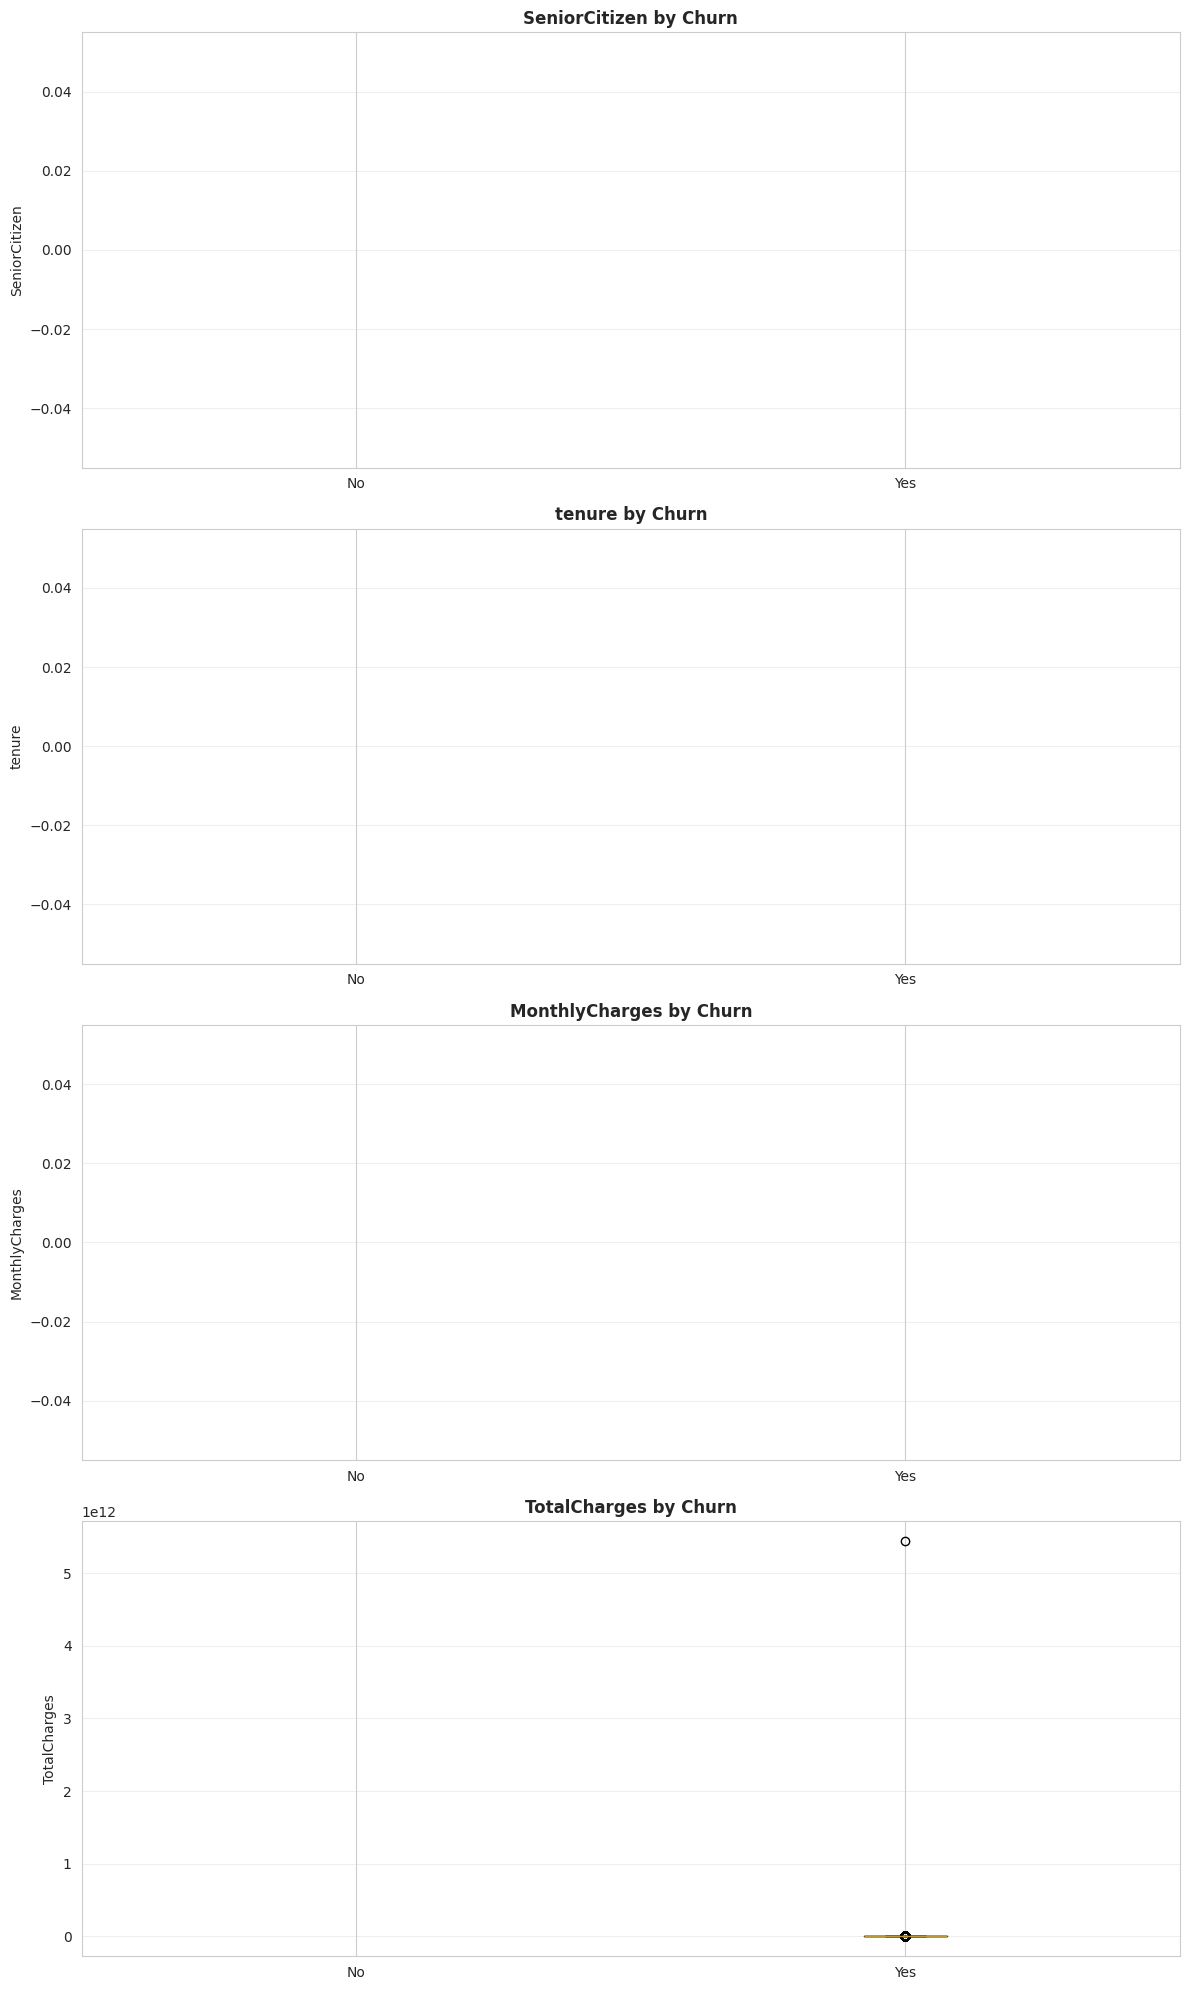

In [28]:
# Numerical vs Categorical Analysis
print("\n" + "=" * 80)
print("NUMERICAL vs CATEGORICAL ANALYSIS")
print("=" * 80)

# Select target variable if exists (likely 'Churn')
target_col = None
if "Churn" in categorical_cols:
    target_col = "Churn"
    print(f"\nTarget variable: {target_col}")
    print(f"Class distribution:\n{df[target_col].value_counts()}")

    # Analyze relationship between numerical variables and target
    fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 5 * len(numerical_cols)))
    if len(numerical_cols) == 1:
        axes = [axes]

    for idx, col in enumerate(numerical_cols):
        churn_groups = df.groupby(target_col)[col].apply(list)
        axes[idx].boxplot(
            [churn_groups[group] for group in churn_groups.index], labels=churn_groups.index
        )
        axes[idx].set_title(f"{col} by {target_col}", fontsize=12, fontweight="bold")
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

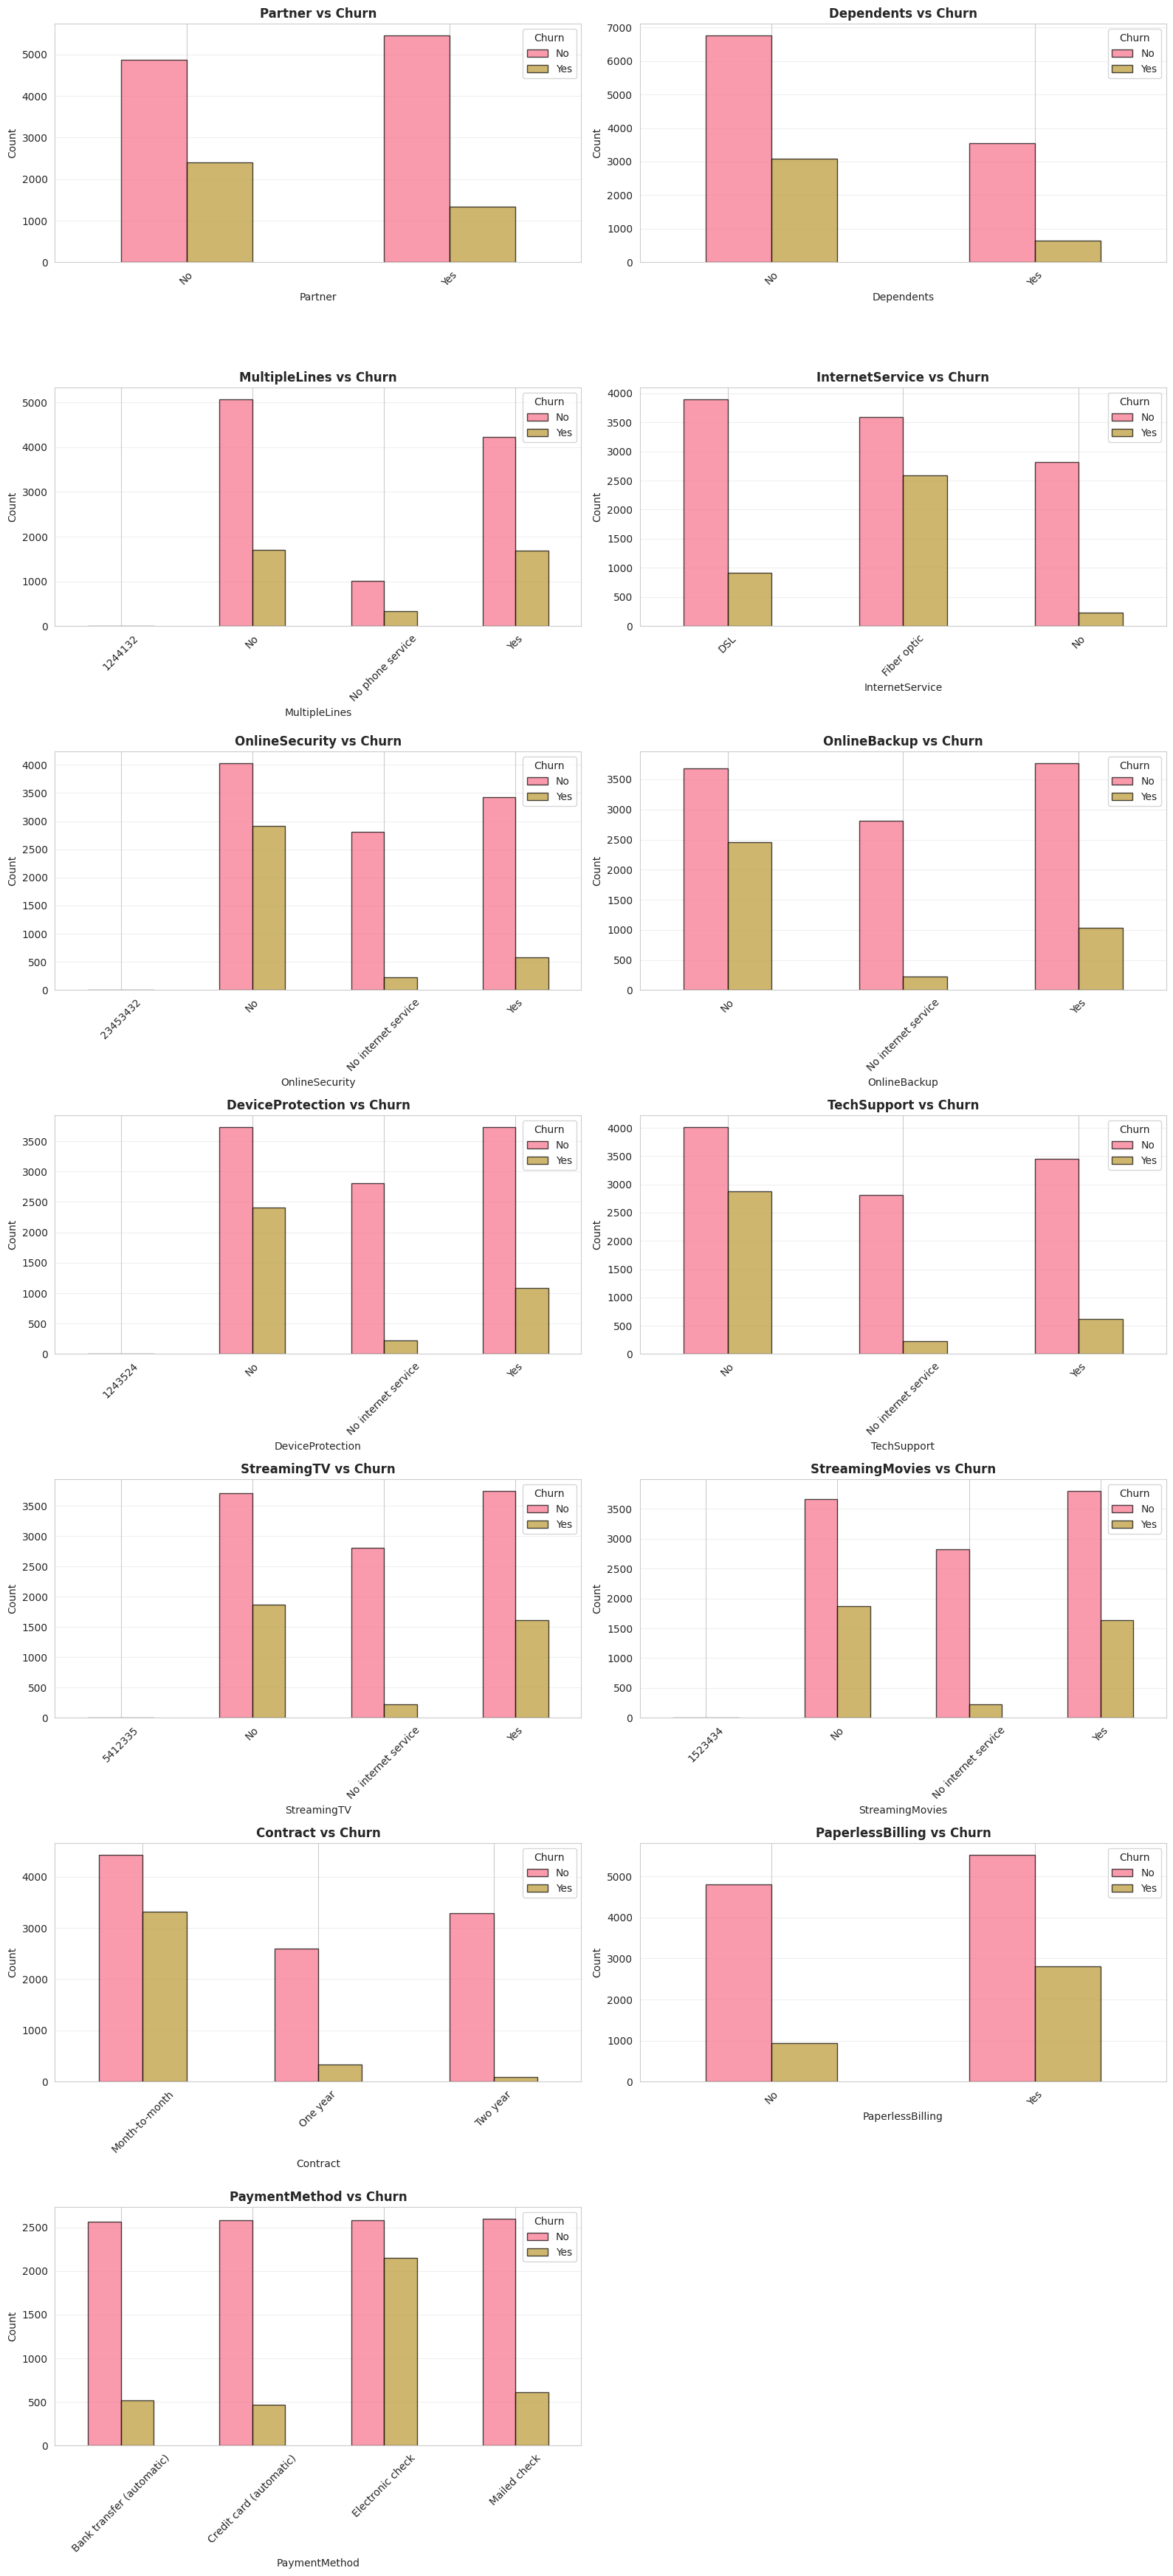

In [29]:
# Categorical vs Categorical Analysis (if target exists)
if target_col:
    other_cat_cols = [col for col in categorical_cols if col != target_col]
    if len(other_cat_cols) > 0:
        fig, axes = plt.subplots(
            (len(other_cat_cols) + 1) // 2, 2, figsize=(16, 5 * ((len(other_cat_cols) + 1) // 2))
        )
        axes = axes.flatten()

        for idx, col in enumerate(other_cat_cols):
            # Create cross-tabulation
            crosstab = pd.crosstab(df[col], df[target_col])
            crosstab.plot(kind="bar", ax=axes[idx], edgecolor="black", alpha=0.7)
            axes[idx].set_title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel("Count")
            axes[idx].legend(title=target_col, loc="upper right")
            axes[idx].tick_params(axis="x", rotation=45)
            axes[idx].grid(axis="y", alpha=0.3)

        for idx in range(len(other_cat_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

### 3️⃣ Multivariable Analysis
Analysis of relationships among multiple variables simultaneously

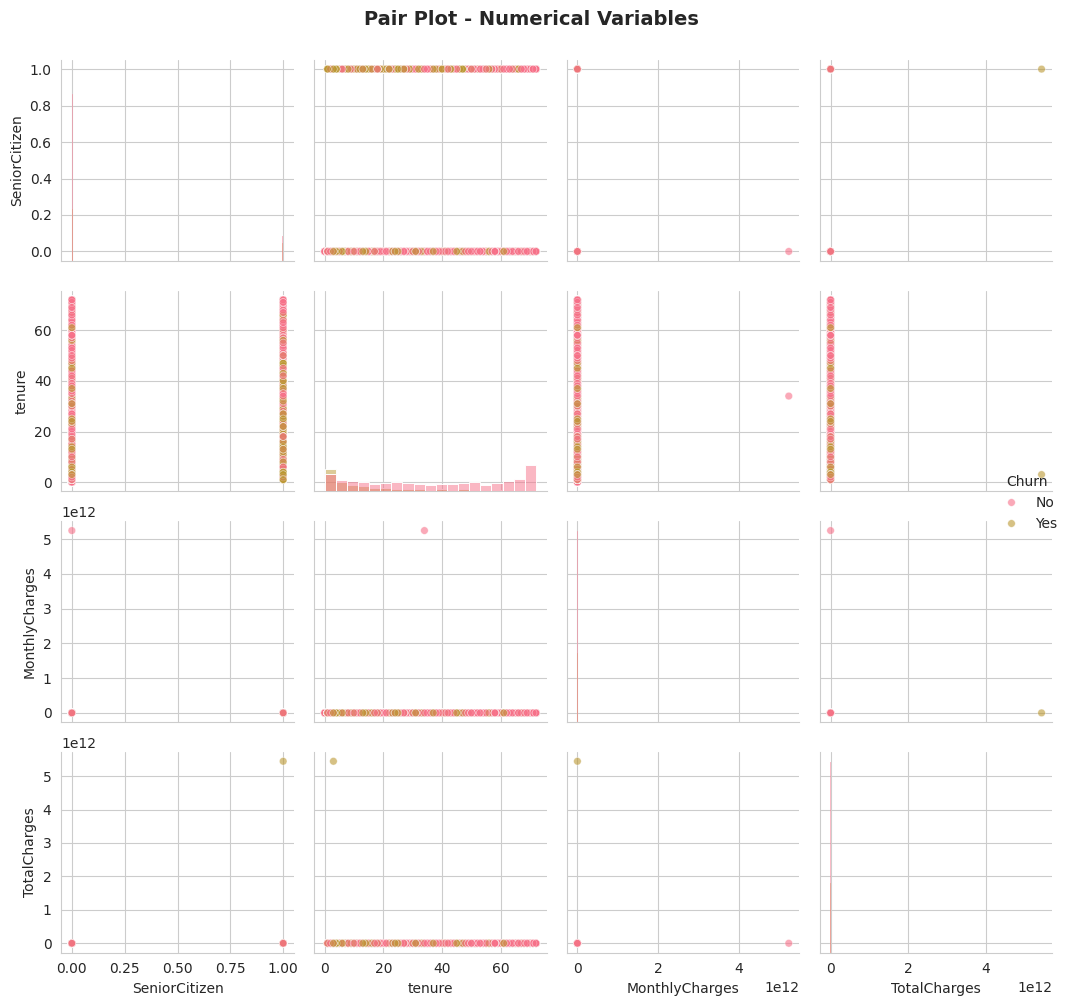

In [30]:
# Pair Plot for Numerical Variables
if len(numerical_cols) >= MIN_NUMERICAL_COLS:
    # Create a subset with numerical columns and target if available
    if target_col:
        plot_df = df[[*numerical_cols, target_col]].copy()
        pairplot = sns.pairplot(
            plot_df, hue=target_col, diag_kind="hist", plot_kws={"alpha": 0.6, "s": 30}, height=2.5
        )
    else:
        plot_df = df[numerical_cols].copy()
        pairplot = sns.pairplot(
            plot_df, diag_kind="hist", plot_kws={"alpha": 0.6, "s": 30}, height=2.5
        )
    pairplot.fig.suptitle(
        "Pair Plot - Numerical Variables", y=1.001, fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

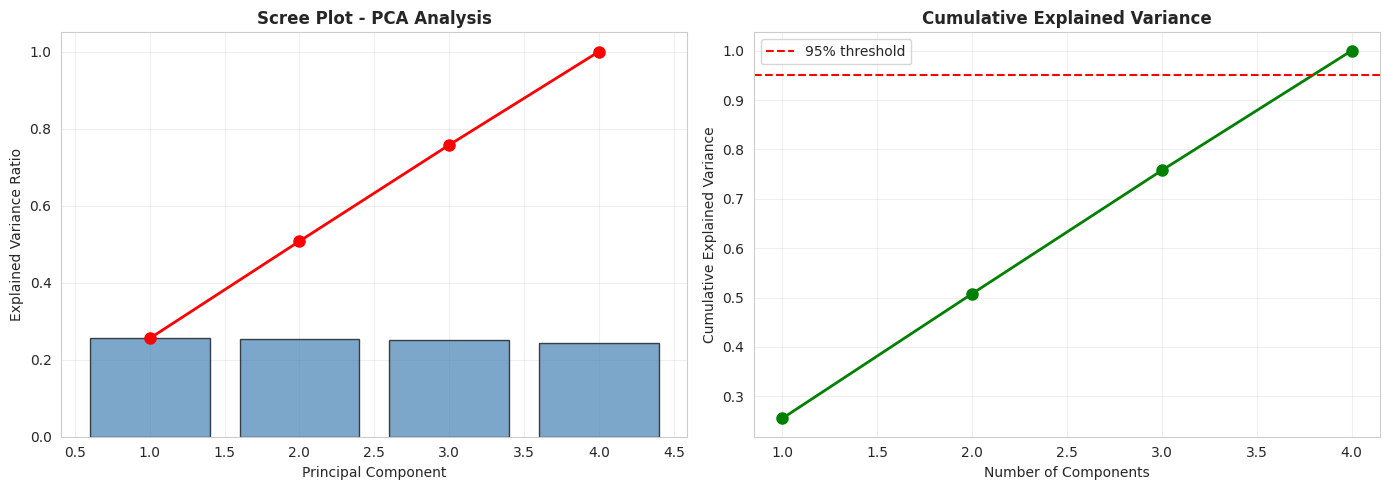


PCA - EXPLAINED VARIANCE
Number of features: 4
PC1: 0.2552 (Cumulative: 0.2552)
PC2: 0.2524 (Cumulative: 0.5076)
PC3: 0.2500 (Cumulative: 0.7576)
PC4: 0.2424 (Cumulative: 1.0000)


ValueError: 'c' argument has 14214 elements, which is inconsistent with 'x' and 'y' with size 13997.

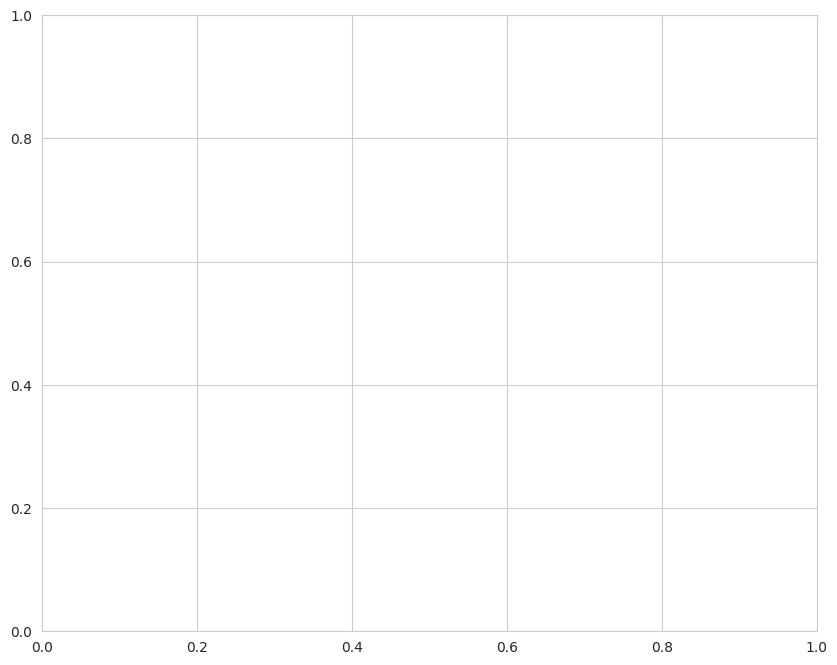

In [ ]:
# Principal Component Analysis (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if len(numerical_cols) >= MIN_NUMERICAL_COLS:
    # Standardize numerical features (keep track of non-NaN indices)
    numerical_data = df[numerical_cols].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(numerical_data)

    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(scaled_data)

    # Explained variance
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scree Plot
    axes[0].bar(
        range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.7,
        color="steelblue",
        edgecolor="black",
    )
    axes[0].plot(
        range(1, len(pca.explained_variance_ratio_) + 1),
        cumsum_var,
        "ro-",
        linewidth=2,
        markersize=8,
    )
    axes[0].set_xlabel("Principal Component")
    axes[0].set_ylabel("Explained Variance Ratio")
    axes[0].set_title("Scree Plot - PCA Analysis", fontsize=12, fontweight="bold")
    axes[0].grid(alpha=0.3)

    # Cumulative Variance
    axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, "go-", linewidth=2, markersize=8)
    axes[1].axhline(y=0.95, color="r", linestyle="--", label="95% threshold")
    axes[1].set_xlabel("Number of Components")
    axes[1].set_ylabel("Cumulative Explained Variance")
    axes[1].set_title("Cumulative Explained Variance", fontsize=12, fontweight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print variance explained
    print("\n" + "=" * 80)
    print("PCA - EXPLAINED VARIANCE")
    print("=" * 80)
    print(f"Number of features: {len(numerical_cols)}")
    for i in range(min(5, len(pca.explained_variance_ratio_))):
        print(
            f"PC{i + 1}: {pca.explained_variance_ratio_[i]:.4f} (Cumulative: {cumsum_var[i]:.4f})"
        )

    # 2D PCA Visualization
    if target_col:
        # Map target to numerical values for coloring — use same index as dropna
        target_map = {cat: i for i, cat in enumerate(df[target_col].unique())}
        colors = df.loc[numerical_data.index, target_col].map(target_map)

        fig, ax = plt.subplots(figsize=(10, 8))
        scatter = ax.scatter(
            pca_result[:, 0],
            pca_result[:, 1],
            c=colors,
            cmap="viridis",
            alpha=0.6,
            s=50,
            edgecolor="black",
        )
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
        ax.set_title("PCA: 2D Visualization by Target Variable", fontsize=12, fontweight="bold")

        # Add legend
        unique_targets = df[target_col].unique()
        handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=plt.cm.viridis(target_map[t] / len(unique_targets)),
                markersize=10,
                label=str(t),
            )
            for t in unique_targets
        ]
        ax.legend(handles=handles, title=target_col, loc="best")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


FEATURE IMPORTANCE ANALYSIS

Numerical Features - Correlation with Churn:
  tenure: 0.3506
  SeniorCitizen: 0.1484
  MonthlyCharges: 0.0050

Categorical Features - Chi-Square Test with Churn:
  Partner: χ²=316.0174, p-value=0.000000 ***
  Dependents: χ²=366.5151, p-value=0.000000 ***
  MultipleLines: χ²=22.4196, p-value=0.000053 ***
  InternetService: χ²=1419.1345, p-value=0.000000 ***
  OnlineSecurity: χ²=1664.3339, p-value=0.000000 ***
  OnlineBackup: χ²=1162.9074, p-value=0.000000 ***
  DeviceProtection: χ²=1083.9376, p-value=0.000000 ***
  TechSupport: χ²=1612.2680, p-value=0.000000 ***
  StreamingTV: χ²=732.6469, p-value=0.000000 ***
  StreamingMovies: χ²=737.9351, p-value=0.000000 ***
  Contract: χ²=2337.7542, p-value=0.000000 ***
  PaperlessBilling: χ²=503.7592, p-value=0.000000 ***
  PaymentMethod: χ²=1252.7131, p-value=0.000000 ***
  TotalCharges: χ²=13102.2687, p-value=0.000000 ***


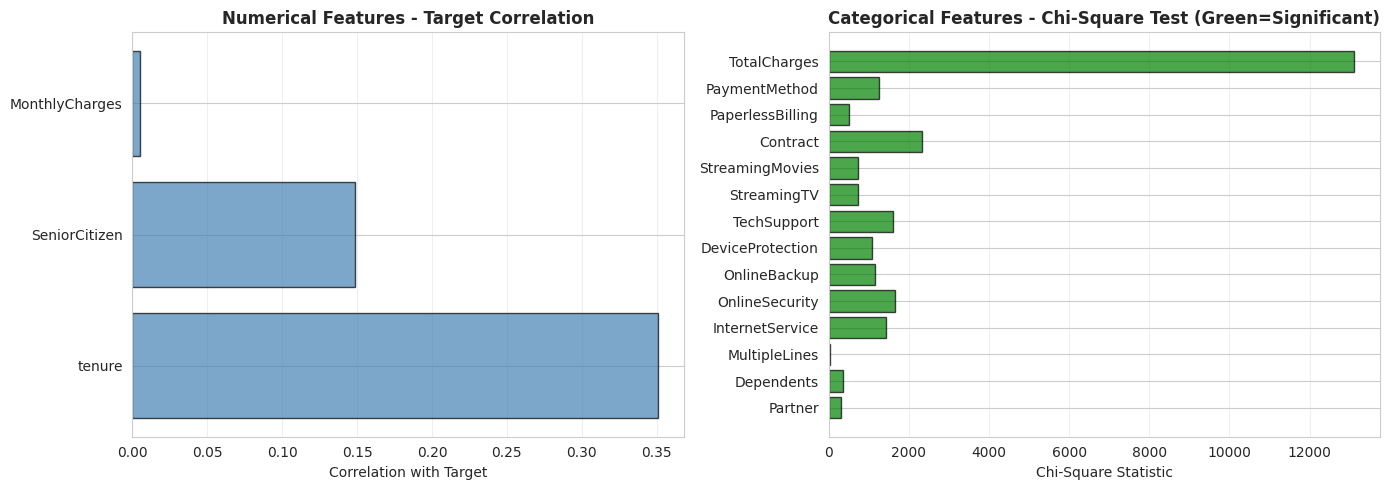

In [ ]:
# Feature Importance Analysis
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

if target_col:
    # Numerical features - Correlation with target (convert to numeric)
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    target_encoded = le.fit_transform(df[target_col])
    # Keep target as a Series aligned to df's index to avoid row-misalignment
    # when a numerical column has NaN values
    target_encoded_s = pd.Series(target_encoded, index=df.index)

    print(f"\nNumerical Features - Correlation with {target_col}:")
    correlations = {}
    for col in numerical_cols:
        valid_idx = df[col].dropna().index
        corr = abs(np.corrcoef(df.loc[valid_idx, col], target_encoded_s.loc[valid_idx])[0, 1])
        if not np.isnan(corr):
            correlations[col] = corr

    sorted_correlations = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
    for feature, corr in sorted_correlations:
        print(f"  {feature}: {corr:.4f}")

    # Chi-square test for categorical features
    from scipy.stats import chi2_contingency

    print(f"\nCategorical Features - Chi-Square Test with {target_col}:")
    chi_square_results = {}
    for col in categorical_cols:
        if col != target_col:
            contingency = pd.crosstab(df[col], df[target_col])
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            chi_square_results[col] = {"chi2": chi2, "p_value": p_value}
            significance = (
                "***"
                if p_value < P_VALUE_SIGNIFICANCE_001
                else "**"
                if p_value < P_VALUE_SIGNIFICANCE_01
                else "*"
                if p_value < P_VALUE_SIGNIFICANCE_05
                else "ns"
            )
            print(f"  {col}: χ²={chi2:.4f}, p-value={p_value:.6f} {significance}")

    # Visualize feature importance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if correlations:
        features = [x[0] for x in sorted_correlations]
        scores = [x[1] for x in sorted_correlations]
        axes[0].barh(features, scores, color="steelblue", edgecolor="black", alpha=0.7)
        axes[0].set_xlabel("Correlation with Target")
        axes[0].set_title("Numerical Features - Target Correlation", fontsize=12, fontweight="bold")
        axes[0].grid(axis="x", alpha=0.3)

    if chi_square_results:
        features = list(chi_square_results.keys())
        chi2_scores = [chi_square_results[f]["chi2"] for f in features]
        colors = [
            "green" if chi_square_results[f]["p_value"] < P_VALUE_SIGNIFICANCE_05 else "lightcoral"
            for f in features
        ]
        axes[1].barh(features, chi2_scores, color=colors, edgecolor="black", alpha=0.7)
        axes[1].set_xlabel("Chi-Square Statistic")
        axes[1].set_title(
            "Categorical Features - Chi-Square Test (Green=Significant)",
            fontsize=12,
            fontweight="bold",
        )
        axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

## 📊 Analysis of Results and Conclusions 

### Summary of Findings

#### Univariable Analysis Insights:
- Identified numerical and categorical feature distributions
- Analyzed skewness, kurtosis, and outliers in numerical features  
- Examined frequency distributions and unique values in categorical features

#### Bivariable Analysis Insights:
- Correlation patterns among numerical variables identified
- Relationships between target variable and individual features explored
- Cross-tabulation analysis reveals associations between categorical variables

#### Multivariable Analysis Insights:
- PCA reveals data dimensionality and variance structure
- Feature importance rankings identify most predictive variables
- Pair plots show complex relationships across multiple variables simultaneously

**Note:** These analyses provide the foundation for feature engineering and model development. The identified patterns and relationships should guide the selection of features for predictive modeling.

In [ ]:
# Summary Statistics
print("\n" + "=" * 80)
print("COMPREHENSIVE EDA SUMMARY")
print("=" * 80)

print(f"\n📊 Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n🔢 Numerical Features: {len(numerical_cols)}")
print(f"  {', '.join(numerical_cols)}")

print(f"\n📝 Categorical Features: {len(categorical_cols)}")
print(f"  {', '.join(categorical_cols)}")

print("\n❌ Missing Values:")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print(missing_data[missing_data > 0])
else:
    print("  No missing values detected")

if target_col:
    print(f"\n🎯 Target Variable: {target_col}")
    print(f"  Class distribution:\n{df[target_col].value_counts()}")
    churn_rate = (df[target_col].value_counts() / len(df) * 100).to_dict()
    for class_label, rate in churn_rate.items():
        print(f"    {class_label}: {rate:.2f}%")

print("\n" + "=" * 80)


COMPREHENSIVE EDA SUMMARY

📊 Dataset Dimensions: 14214 rows × 18 columns

🔢 Numerical Features: 3
  SeniorCitizen, tenure, MonthlyCharges

📝 Categorical Features: 15
  Partner, Dependents, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, TotalCharges, Churn

❌ Missing Values:
  No missing values detected

🎯 Target Variable: Churn
  Class distribution:
Churn
No     10454
Yes     3760
Name: count, dtype: int64
    No: 73.55%
    Yes: 26.45%



## 💡 Proposals and Ideas

### Feature Engineering Opportunities:
1. **Polynomial Features**: Create interaction terms between highly correlated numerical variables
2. **Scaling**: Normalize/standardize numerical features for distance-based models
3. **Encoding**: Apply appropriate encoding (one-hot, ordinal) to categorical variables
4. **Feature Selection**: Use correlation and chi-square results to remove redundant features

### Modeling Recommendations:
1. Consider ensemble methods (Random Forest, Gradient Boosting) for feature importance ranking
2. Apply dimensionality reduction techniques if number of features becomes problematic
3. Investigate class imbalance (if applicable) using appropriate sampling techniques
4. Validate findings with holdout test set before drawing final conclusions

### Further Analysis:
1. Perform time-series analysis if temporal data is available
2. Investigate outliers and their impact on model performance
3. Conduct business logic validation of identified relationships
4. Explore domain-specific feature engineering based on expert knowledge

In [ ]:
# Save summary statistics to file
summary_stats = {
    "shape": df.shape,
    "numerical_cols": numerical_cols,
    "categorical_cols": categorical_cols,
    "missing_values": df.isnull().sum().to_dict(),
    "target_col": target_col,
}

print("✅ EDA Complete!")
print("\nKey Takeaways:")
print("  • Checked univariable distributions and outliers")
print("  • Analyzed bivariable relationships and correlations")
print("  • Performed multivariable analysis including PCA")
print("  • Ranked feature importance relative to target variable")
print("  • Generated actionable insights for feature engineering and modeling")

✅ EDA Complete!

Key Takeaways:
  • Checked univariable distributions and outliers
  • Analyzed bivariable relationships and correlations
  • Performed multivariable analysis including PCA
  • Ranked feature importance relative to target variable
  • Generated actionable insights for feature engineering and modeling


## 📖 References

### EDA Best Practices:
- [Exploratory Data Analysis Best Practices](https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15)
- [Statistical Methods for Data Analysis](https://en.wikipedia.org/wiki/Exploratory_data_analysis)

### Python Libraries:
- **Pandas**: Data manipulation and analysis
- **Seaborn & Matplotlib**: Data visualization
- **Scikit-learn**: Machine learning and preprocessing
- **SciPy**: Statistical analysis

### Analysis Techniques:
- **PCA**: Principal Component Analysis for dimensionality reduction
- **Correlation Analysis**: Understanding linear relationships
- **Chi-Square Test**: Testing independence of categorical variables
- **Box Plots & Histograms**: Visualizing distributions and outliers